In [ ]:
# Resolve the GridX project root after this notebook moved to notebooks/.
from pathlib import Path
import os
import sys

project_root = Path.cwd().resolve()
if not (project_root / "src").is_dir():
    project_root = project_root.parent
if not (project_root / "src").is_dir():
    raise RuntimeError("Run this notebook from the GridX repository.")
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))


# OSM中国高压输电网络GIS清洗与拓扑重构

本notebook从OSM电力设施GeoPackage出发，完成电压与交直流属性清洗、
线路分段、terminal与substation空间匹配、NetworkX拓扑重构、统计校验和地图输出。
`lines`、`substations`、`segments`、`terminals`保留GIS处理语义；
`nodes`和`branches`仅用于最终抽象电网。

## 1. 运行环境与集中配置

第一组cell导入依赖，并集中定义输入输出路径、OSM电压阈值、terminal匹配距离、
米制投影及通用地图尺寸。修改这些参数即可改变拓扑筛选、空间匹配和输出分辨率，
无需在后续处理cell中寻找硬编码常量。

In [1]:
from IPython.core.interactiveshell import InteractiveShell

InteractiveShell.ast_node_interactivity = "all"

import argparse
import re
from pathlib import Path
from shapely.geometry import Point
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

pd.set_option("display.max_columns", None)
pd.set_option("display.expand_frame_repr", False)

# Notebook-level paths and topology thresholds.
osm_file_path = Path("data/osm/china-power-network.gpkg")
province_file_path = Path("data/china_provinces_datav_clean.geojson")
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

min_line_voltage = 500 * 1000
min_station_voltage = 220 * 1000
terminal_station_buffer_m = 500
terminal_inside_tolerance_m = 1e-6
metric_crs = (
    "+proj=aea +lat_1=25 +lat_2=47 "
    "+lat_0=0 +lon_0=105 +datum=WGS84 +units=m +no_defs"
)

map_figure_size = (14, 11)
map_dpi = 300

## 2. 读取OSM电力设施

从 `power_features` 图层仅读取拓扑所需字段和
`line/cable/substation/converter` 对象。`@type + @id` 将在下一步组合为
跨OSM node、way和relation命名空间的稳定来源标识。

In [2]:
columns = [
    "@type", "@id",
    "power",
    "voltage",
    "circuits",
    "cables",
    "frequency",
    "operator",
    "name",
    "substation",
    "location",
    "construction",
]
osm_power_features = gpd.read_file(
    osm_file_path,
    layer="power_features",
    engine="pyogrio",
    columns=columns,
    where="power IN ('line', 'cable', 'substation', 'converter')",
    use_arrow=True,
)

## 3. 规范电压、交直流与生命周期对象

解析OSM可能包含多值的 `voltage` 字段并取得最高电压；
根据 `frequency=0` 或名称中的HVDC/直流标记识别直流线路。
随后分别按线路和变电站阈值、对象类型和几何类型生成原始
`lines` 与 `substations`。

In [3]:
def maximum_voltage(value):
    if pd.isna(value):
        return None
    numbers = [float(number) for number in re.findall(r"\d+(?:\.\d+)?", str(value))]
    # OSM requires voltage values in volts.
    voltages = [number for number in numbers if number >= 1000]
    return max(voltages, default=None)

osm_power_features["voltage_max"] = (
    osm_power_features["voltage"].map(maximum_voltage).astype("Float64")
)
osm_power_features["voltage_level"] = osm_power_features["voltage_max"].map(
    lambda value: f"{value / 1000:g} kV"
)

# OSM uses frequency=0 for DC; otherwise assume AC unless the name identifies HVDC.
dc_by_frequency = (
    osm_power_features["frequency"].fillna("").astype(str)
    .str.split(r"[;,/]")
    .map(lambda values: any(value.strip() in {"0", "0.0"} for value in values))
)
dc_by_name = osm_power_features["name"].fillna("").str.contains(
    r"直流|HVDC", case=False, regex=True
)
osm_power_features["current_type"] = "AC"
osm_power_features.loc[dc_by_frequency | dc_by_name, "current_type"] = "DC"
osm_power_features["source_uid"] = (
    osm_power_features["@type"].astype(str) + ":" + osm_power_features["@id"].astype(str)
)

line_voltage_mask = osm_power_features["voltage_max"].ge(min_line_voltage).fillna(False)
station_voltage_mask = osm_power_features["voltage_max"].ge(min_station_voltage).fillna(False)
missing_voltage_mask = osm_power_features["voltage_max"].isna()
line_mask = (
    osm_power_features["power"].isin(["line", "cable"])
    & line_voltage_mask
    & osm_power_features.geometry.geom_type.isin(["LineString", "MultiLineString"])
)
substation_mask = (
    osm_power_features["power"].isin(["substation", "converter"])
    & (station_voltage_mask | missing_voltage_mask)
    & osm_power_features.geometry.geom_type.isin(
        ["Point", "MultiPoint", "Polygon", "MultiPolygon"]
    )
)

# These retain the filtered OSM feature semantics and are not overwritten downstream.
lines = osm_power_features[line_mask].copy()
substations = osm_power_features[substation_mask].copy()

## 4. 线路分段与变电站几何去重

同一OSM变电站可能以点和面重复导出，因此按来源ID和几何优先级去重。
MultiLineString线路展开为独立LineString `segments`，并为每段建立稳定
`segment_uid`，供terminal匹配和后续branch追踪。

In [4]:
# Standardize OSM substations and derive LineString segments from OSM lines.
geometry_rank = {"MultiPolygon": 0, "Polygon": 1, "MultiPoint": 2, "Point": 3}
substations["_geometry_rank"] = substations.geometry.geom_type.map(geometry_rank)
substations = (
    substations.sort_values(["source_uid", "_geometry_rank"])
    .drop_duplicates("source_uid")
    .drop(columns="_geometry_rank")
    .reset_index(drop=True)
)

line_segments = lines.explode(index_parts=True, ignore_index=False).reset_index(
    names=["_line_row", "segment_part"]
)
line_segments = line_segments[line_segments.geometry.geom_type.eq("LineString")].copy()
line_segments["segment_uid"] = (
    line_segments["source_uid"] + "#" + line_segments["segment_part"].astype(str)
)
line_segments = (
    line_segments.drop_duplicates(["source_uid", "segment_uid"]).reset_index(drop=True)
)

## 5. 构造terminals并匹配substations

每个线路segment生成start/end两个terminal。在中国Albers米制投影中，
将变电站几何扩展500米后进行空间相交，并计算terminal到原始变电站几何的
真实距离。结果保存在 `terminal_station_matches`，且保留一对多候选供校验。

In [5]:
# Create segment terminals and spatially match them to OSM substations.
line_segments_metric = line_segments.to_crs(metric_crs)
substations_metric = substations.to_crs(metric_crs)

_terminal_records = []
for segment in line_segments_metric.itertuples():
    coordinates = segment.geometry.coords
    for terminal_position, coordinate in (
        ("start", coordinates[0]),
        ("end", coordinates[-1]),
    ):
        _terminal_records.append({
            "terminal_uid": f"{segment.segment_uid}:{terminal_position}",
            "terminal_position": terminal_position,
            "segment_uid": segment.segment_uid,
            "line_uid": segment.source_uid,
            "line_name": segment.name,
            "line_type": segment.power,
            "line_voltage": segment.voltage,
            "line_voltage_max": segment.voltage_max,
            "line_voltage_level": segment.voltage_level,
            "line_current_type": segment.current_type,
            "geometry": Point(coordinate),
        })

terminals = gpd.GeoDataFrame(
    _terminal_records, geometry="geometry", crs=metric_crs
).drop_duplicates("terminal_uid").reset_index(drop=True)

_substations_for_matching = (
    substations_metric[["source_uid", "name", "power", "voltage", "geometry"]]
    .rename(columns={
        "source_uid": "station_uid",
        "name": "station_name",
        "power": "station_type",
        "voltage": "station_voltage",
    })
    .drop_duplicates("station_uid")
    .reset_index(drop=True)
)
_substation_geometry = _substations_for_matching.geometry.copy()
_substations_for_matching["geometry"] = _substations_for_matching.geometry.buffer(terminal_station_buffer_m)

_terminal_station_join = gpd.sjoin(
    terminals,
    _substations_for_matching,
    how="inner",
    predicate="intersects",
)
_terminal_station_join["distance_m"] = [
    terminal_geometry.distance(_substation_geometry.loc[substation_index])
    for terminal_geometry, substation_index in zip(
        _terminal_station_join.geometry,
        _terminal_station_join["index_right"],
        strict=True,
    )
]
_terminal_station_join["match_method"] = _terminal_station_join["distance_m"].map(
    lambda distance: (
        "terminal_in_station" if distance <= terminal_inside_tolerance_m else "terminal_near_station"
    )
)
terminal_station_matches = (
    _terminal_station_join.sort_values(["terminal_uid", "distance_m"])
    .drop_duplicates(["terminal_uid", "station_uid", "segment_uid"])
    .reset_index(drop=True)
)

## 6. 绘制清洗后的OSM输电网络

在省级边界上按离散电压等级着色、按AC/DC设置线型，并叠加OSM变电站和
已匹配terminal。该图展示GIS清洗结果，尚不是最终抽象拓扑。

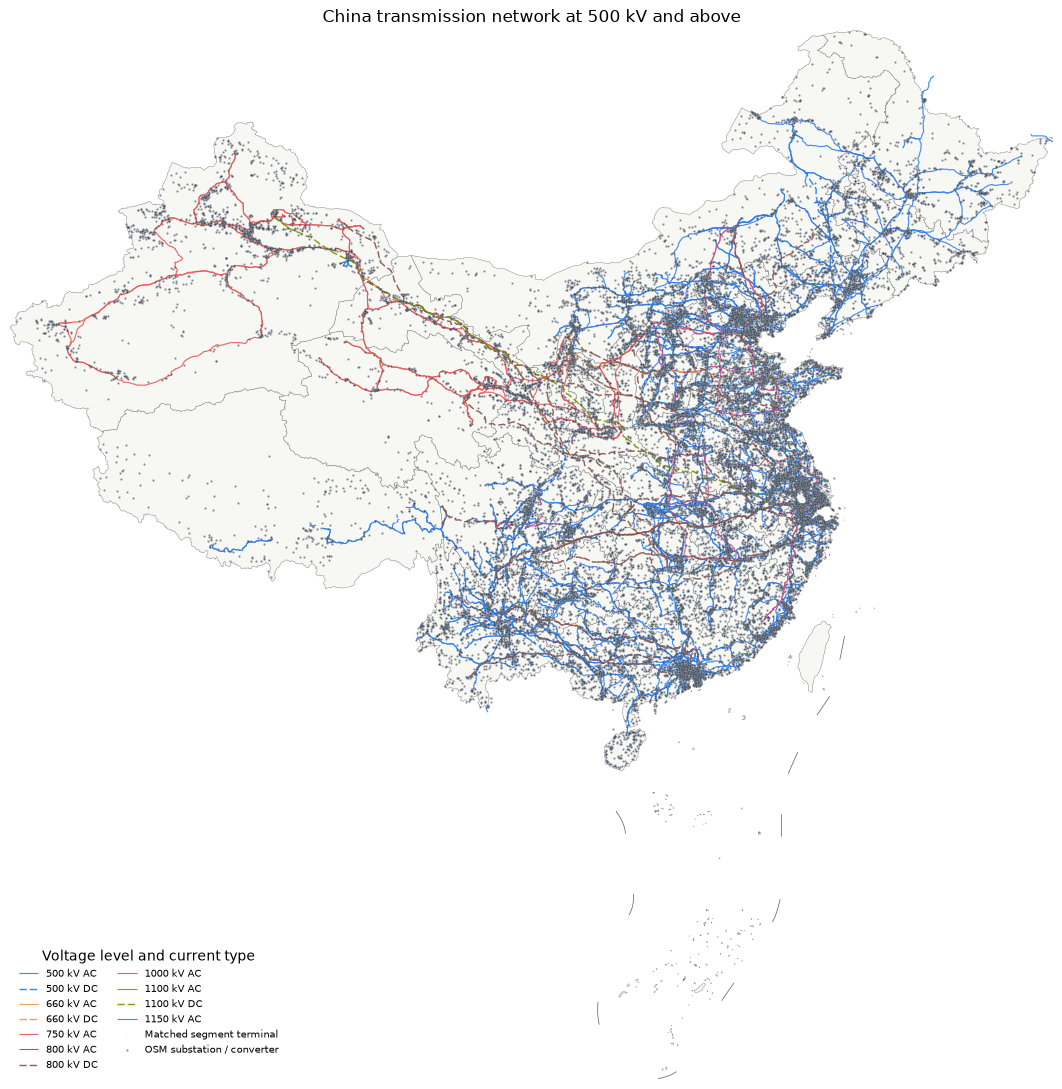

In [6]:
provinces = gpd.read_file(province_file_path)

fig, ax = plt.subplots(figsize=map_figure_size)
voltage_order = sorted(
    lines["voltage_level"].dropna().unique(),
    key=lambda label: float(label.split()[0]),
)
_voltage_colors = [
    "#2F80ED", "#F2994A", "#EB5757", "#8C564B",
    "#D45087", "#7A9A01", "#00A6A6", "#6C5CE7",
]
voltage_styles = {
    level: _voltage_colors[index % len(_voltage_colors)]
    for index, level in enumerate(voltage_order)
}
current_styles = {"AC": "solid", "DC": (0, (5, 2))}

current_crs = lines.crs
provinces = provinces.to_crs(current_crs)
_substation_points = substations.assign(
    geometry=substations.geometry.representative_point()
).to_crs(current_crs)
_matched_terminals = terminal_station_matches.to_crs(current_crs)

_ = provinces.plot(
    ax=ax, facecolor="#f7f7f4", edgecolor="#777777", linewidth=0.30, zorder=1
)
for voltage_level in voltage_order:
    for current_type, linestyle in current_styles.items():
        _selected_lines = lines[
            (lines["voltage_level"] == voltage_level)
            & (lines["current_type"] == current_type)
        ]
        if not _selected_lines.empty:
            _ = _selected_lines.plot(
                ax=ax,
                color=voltage_styles[voltage_level],
                linestyle=linestyle,
                linewidth=1.05 if current_type == "DC" else 0.80,
                alpha=0.92,
                label=f"{voltage_level} {current_type}",
                zorder=3 if current_type == "DC" else 2,
            )

_ = _matched_terminals.plot(
    ax=ax, marker="o", color="#F2A900", markersize=0.45, alpha=0.24,
    linewidth=0, label="Matched segment terminal", zorder=4,
)
_ = _substation_points.plot(
    ax=ax, marker="o", color="#374151", edgecolor="white",
    linewidth=0.10, markersize=2.4, alpha=0.62,
    label="OSM substation / converter", zorder=5,
)
_ = ax.legend(
    loc="lower left", frameon=False, fontsize=7, ncol=2,
    title="Voltage level and current type",
)
_ = ax.set(
    xlim=provinces.total_bounds[[0, 2]],
    ylim=provinces.total_bounds[[1, 3]],
    title=f"China transmission network at {min_line_voltage/1000:g} kV and above",
)
_ = ax.set_axis_off()
plt.tight_layout()
fig.savefig(
    output_dir / "china_transmission_network.png",
    dpi=map_dpi,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

## 7. 重构电网拓扑并关联省份

以下代码把匹配后的线路terminal转换成最终的graph nodes和graph branches。
OSM变电站对应 `station` node；没有匹配到变电站的线路端点按坐标和电压等级
构造 `junction` node。同一物理变电站可以连接不同电压等级的线路，
junction之间则只能通过原始同电压线路segment连接。

`grid_topology` 构建完成后立即将每个node与省级多边形进行空间连接，
并把 `node_province_name` 及布尔属性 `province_intersection_matched`
直接写入NetworkX node。后者明确表示node是否与省界多边形严格相交；
后续GeoDataFrame只展开已经存在的拓扑属性，不再反向修改 `grid_topology`。

In [7]:
# Assign each matched terminal to its nearest OSM substation.
terminal_station_assignments = (
    terminal_station_matches.to_crs(metric_crs)
    .sort_values(["terminal_uid", "distance_m"])
    .drop_duplicates("terminal_uid")
    .reset_index(drop=True)
)
_terminal_station_lookup = terminal_station_assignments.set_index(
    "terminal_uid"
)["station_uid"]

# Direct graph branches are segments whose two terminals match different stations.
_direct_branch_ends = (
    terminal_station_assignments.pivot(
        index="segment_uid", columns="terminal_position", values="station_uid"
    )
    .dropna(subset=["start", "end"])
    .query("start != end")
    .rename(columns={"start": "from_station", "end": "to_station"})
    .reset_index()
)
direct_branches = gpd.GeoDataFrame(
    _direct_branch_ends.merge(
        line_segments_metric[[
            "segment_uid", "source_uid", "name", "voltage_max",
            "current_type", "circuits", "geometry",
        ]],
        on="segment_uid",
    ).rename(columns={"source_uid": "line_uid", "name": "line_name"}),
    geometry="geometry",
    crs=metric_crs,
)
direct_branches["branch_uid"] = direct_branches["segment_uid"]
direct_branches["voltage_kv"] = (
    direct_branches["voltage_max"] / 1000
).astype("Int64")
direct_branches["length_km"] = direct_branches.length / 1000

# Stations are physical nodes across voltages; junction nodes are voltage-specific.
_station_metadata = (
    substations_metric[[
        "source_uid", "name", "power", "voltage", "operator",
        "frequency", "substation", "location", "construction", "geometry",
    ]]
    .drop_duplicates("source_uid")
    .rename(
        columns={
            "source_uid": "station_uid",
            "name": "station_name",
            "power": "station_osm_type",
            "voltage": "station_osm_voltage",
            "operator": "station_operator",
            "frequency": "station_frequency",
            "substation": "station_class",
            "location": "station_location",
            "construction": "station_construction",
        }
    )
    .set_index("station_uid")
)
_station_points = _station_metadata.geometry.representative_point()
grid_topology = nx.MultiGraph(crs=metric_crs)

for segment in line_segments_metric.itertuples():
    _voltage_kv = int(segment.voltage_max / 1000)
    _terminal_positions = ("start", "end")
    _coordinates = [segment.geometry.coords[index] for index in (0, -1)]
    _stations = [
        _terminal_station_lookup.get(f"{segment.segment_uid}:{terminal_position}")
        for terminal_position in _terminal_positions
    ]
    _branch_nodes = [
        station if station is not None else (
            "junction",
            round(float(coordinate[0]), 3),
            round(float(coordinate[1]), 3),
            _voltage_kv,
        )
        for station, coordinate in zip(_stations, _coordinates, strict=True)
    ]

    for node, station, coordinate in zip(
        _branch_nodes, _stations, _coordinates, strict=True
    ):
        _is_station = station is not None
        _station = _station_metadata.loc[station] if _is_station else None
        _ = grid_topology.add_node(
            node,
            node_type="station" if _is_station else "junction",
            station_uid=station,
            station_name=_station["station_name"] if _is_station else None,
            station_osm_type=_station["station_osm_type"] if _is_station else None,
            station_osm_voltage=_station["station_osm_voltage"] if _is_station else None,
            station_operator=_station["station_operator"] if _is_station else None,
            station_frequency=_station["station_frequency"] if _is_station else None,
            station_class=_station["station_class"] if _is_station else None,
            station_location=_station["station_location"] if _is_station else None,
            station_construction=(
                _station["station_construction"] if _is_station else None
            ),
            voltage_kv=None if _is_station else _voltage_kv,
            geometry=_station_points.get(station) if _is_station else Point(coordinate),
        )

    # NetworkX calls branches "edges"; business-facing names use "branch".
    if _branch_nodes[0] != _branch_nodes[1]:
        _ = grid_topology.add_edge(
            *_branch_nodes,
            key=segment.segment_uid,
            branch_uid=segment.segment_uid,
            branch_type="line_segment",
            segment_uid=segment.segment_uid,
            line_uid=segment.source_uid,
            line_name=segment.name,
            operator=segment.operator,
            frequency=segment.frequency,
            cables=segment.cables,
            construction=segment.construction,
            voltage_kv=_voltage_kv,
            voltage_level=segment.voltage_level,
            current_type=segment.current_type,
            circuits=segment.circuits,
            length_m=segment.geometry.length,
            geometry=segment.geometry,
        )

# Record all incident branch voltages on every final graph node.
for _node in grid_topology.nodes:
    grid_topology.nodes[_node]["node_voltage_levels_kv"] = sorted({
        int(_branch["voltage_kv"])
        for *_, _branch in grid_topology.edges(_node, data=True)
        if pd.notna(_branch.get("voltage_kv"))
    })


# Attach province membership directly to graph nodes before creating GIS views.
province_polygons = provinces[
    provinces.geometry.geom_type.isin(["Polygon", "MultiPolygon"])
    & provinces["name"].ne("JD")
][["name", "geometry"]].rename(columns={"name": "province_name"})

_graph_node_points = gpd.GeoDataFrame(
    [
        {"node_uid": node, "geometry": node_data["geometry"]}
        for node, node_data in grid_topology.nodes(data=True)
    ],
    geometry="geometry",
    crs=metric_crs,
)
_node_province_matches = gpd.sjoin(
    _graph_node_points,
    province_polygons.to_crs(metric_crs),
    how="left",
    predicate="intersects",
).sort_values("province_name", na_position="last")
_node_province_matches = _node_province_matches.loc[
    ~_node_province_matches.index.duplicated(keep="first")
]
_node_province_by_uid = dict(zip(
    _node_province_matches["node_uid"],
    _node_province_matches["province_name"].where(
        _node_province_matches["province_name"].notna(), None
    ),
    strict=True,
))
nx.set_node_attributes(
    grid_topology,
    _node_province_by_uid,
    "node_province_name",
)
nx.set_node_attributes(
    grid_topology,
    {
        node: pd.notna(province_name)
        for node, province_name in _node_province_by_uid.items()
    },
    "province_intersection_matched",
)


## 8. 查询任意两个变电站的连接

`station_connection` 在重构图中查询两个station node之间的最短路径。
`direct_only=True` 仅接受单条直接branch；关闭后可返回经过junction的
同电压线路路径，并汇总实际线路长度。

In [8]:
def station_connection(station_a, station_b, direct_only=True):
    """Return the shortest geographic branch path between two station nodes."""
    if station_a not in grid_topology or station_b not in grid_topology:
        return pd.DataFrame()

    _allowed_nodes = [
        node for node, node_data in grid_topology.nodes(data=True)
        if not direct_only
        or node_data["node_type"] != "station"
        or node in {station_a, station_b}
    ]
    _path_graph = grid_topology.subgraph(_allowed_nodes)
    try:
        _node_path = nx.shortest_path(
            _path_graph, station_a, station_b, weight="length_m"
        )
    except nx.NetworkXNoPath:
        return pd.DataFrame()

    _branches = [
        min(
            _path_graph.get_edge_data(node_a, node_b).values(),
            key=lambda branch: branch["length_m"],
        )
        for node_a, node_b in zip(_node_path[:-1], _node_path[1:])
    ]
    return pd.DataFrame([{
        "length_km": sum(branch["length_m"] for branch in _branches) / 1000,
        "voltage_path_kv": tuple(
            dict.fromkeys(branch["voltage_kv"] for branch in _branches)
        ),
        "station_path": tuple(
            node for node in _node_path
            if grid_topology.nodes[node]["node_type"] == "station"
        ),
        "branch_uids": tuple(branch["branch_uid"] for branch in _branches),
        "segment_uids": tuple(branch["segment_uid"] for branch in _branches),
        "line_uids": tuple(dict.fromkeys(branch["line_uid"] for branch in _branches)),
    }])

## 9. Grid summary与独立交叉检查

所有统计项均按自身定义从原始匹配表或最终图直接计算。
`grid_summary` 描述规模和连通性；`grid_summary_check` 单独检查互补关系、
branch分类闭合和电压连接规则，避免把验证布尔值混入主体统计。

In [9]:
# Calculate every statistic directly from its own definition.
_terminal_substation_counts = (
    terminal_station_matches.groupby("terminal_uid")["station_uid"].nunique()
)
_substation_terminal_counts = (
    terminal_station_matches.groupby("station_uid")["terminal_uid"].nunique()
)
_matched_terminal_count = terminal_station_matches["terminal_uid"].nunique()
_matched_substation_count = terminal_station_matches["station_uid"].nunique()
_single_substation_terminal_uids = _terminal_substation_counts[
    _terminal_substation_counts.eq(1)
].index
_single_substation_terminal_count = len(_single_substation_terminal_uids)
_multiple_substation_terminal_count = _terminal_substation_counts.gt(1).sum()
_single_match_relations = (
    terminal_station_matches[
        terminal_station_matches["terminal_uid"].isin(_single_substation_terminal_uids)
    ][["terminal_uid", "station_uid"]]
    .drop_duplicates()
)
_shared_substation_single_match_terminal_count = (
    _single_match_relations[
        _single_match_relations["station_uid"].map(_substation_terminal_counts).gt(1)
    ]["terminal_uid"].nunique()
)
_one_to_one_terminal_substation_match_count = (
    _single_match_relations[
        _single_match_relations["station_uid"].map(_substation_terminal_counts).eq(1)
    ]["terminal_uid"].nunique()
)
_assigned_terminal_count = terminal_station_assignments["terminal_uid"].nunique()
_assigned_substation_count = terminal_station_assignments["station_uid"].nunique()

_graph_node_count = grid_topology.number_of_nodes()
_station_node_uids = [
    node for node, node_data in grid_topology.nodes(data=True)
    if node_data["node_type"] == "station"
]
_junction_node_uids = [
    node for node, node_data in grid_topology.nodes(data=True)
    if node_data["node_type"] == "junction"
]
_station_node_count = len(_station_node_uids)
_junction_node_count = len(_junction_node_uids)
_multi_voltage_station_node_count = sum(
    len({
        branch["voltage_kv"]
        for *_, branch in grid_topology.edges(node, data=True)
    }) > 1
    for node in _station_node_uids
)

_graph_branch_count = grid_topology.number_of_edges()
_direct_branch_count = direct_branches["branch_uid"].nunique()
_station_to_station_branch_count = sum(
    grid_topology.nodes[node_a]["node_type"] == "station"
    and grid_topology.nodes[node_b]["node_type"] == "station"
    for node_a, node_b in grid_topology.edges()
)
_station_to_junction_branch_count = sum(
    {
        grid_topology.nodes[node_a]["node_type"],
        grid_topology.nodes[node_b]["node_type"],
    } == {"station", "junction"}
    for node_a, node_b in grid_topology.edges()
)
_junction_to_junction_branch_count = sum(
    grid_topology.nodes[node_a]["node_type"] == "junction"
    and grid_topology.nodes[node_b]["node_type"] == "junction"
    for node_a, node_b in grid_topology.edges()
)
_branch_types = tuple(sorted({
    branch["branch_type"] for *_, branch in grid_topology.edges(data=True)
}))
_branch_voltage_consistent = all(
    (grid_topology.nodes[node_a]["node_type"] == "station"
     or grid_topology.nodes[node_a]["voltage_kv"] == branch["voltage_kv"])
    and (grid_topology.nodes[node_b]["node_type"] == "station"
         or grid_topology.nodes[node_b]["voltage_kv"] == branch["voltage_kv"])
    for node_a, node_b, branch in grid_topology.edges(data=True)
)

_connected_subgraphs = list(nx.connected_components(grid_topology))
_connected_subgraph_count = len(_connected_subgraphs)
_isolated_node_subgraph_count = sum(
    len(connected_subgraph_nodes) == 1
    and grid_topology.subgraph(connected_subgraph_nodes).number_of_edges() == 0
    for connected_subgraph_nodes in _connected_subgraphs
)
_isolated_branch_count = sum(
    len(connected_subgraph_nodes) == 2
    and grid_topology.subgraph(connected_subgraph_nodes).number_of_edges() == 1
    for connected_subgraph_nodes in _connected_subgraphs
)
_multi_branch_connected_subgraph_count = sum(
    grid_topology.subgraph(connected_subgraph_nodes).number_of_edges() >= 2
    for connected_subgraph_nodes in _connected_subgraphs
)
_largest_connected_graph = max(_connected_subgraphs, key=len, default=set())
_largest_connected_graph_node_count = len(_largest_connected_graph)
_largest_connected_graph_branch_count = grid_topology.subgraph(
    _largest_connected_graph
).number_of_edges()

_largest_connected_graph_station_node_count = sum(
    node_data["node_type"] == "station"
    for node, node_data in grid_topology.nodes(data=True)
    if node in _largest_connected_graph
)
_largest_connected_graph_unassigned_station_node_count = sum(
    node_data["node_type"] == "station"
    and not node_data["province_intersection_matched"]
    for node, node_data in grid_topology.nodes(data=True)
    if node in _largest_connected_graph
)

# Attach connectivity once; all later GIS views inherit it from the graph.
nx.set_node_attributes(
    grid_topology,
    {
        node: node in _largest_connected_graph
        for node in grid_topology.nodes
    },
    "in_largest_connected_graph",
)
for _node_a, _node_b, _key, _branch in grid_topology.edges(
    keys=True, data=True
):
    _branch["in_largest_connected_graph"] = (
        _node_a in _largest_connected_graph
        and _node_b in _largest_connected_graph
    )

# Cross-check expected relationships only after all counts have been measured independently.
_terminal_match_partition_valid = (
    _matched_terminal_count
    == _single_substation_terminal_count + _multiple_substation_terminal_count
)
_single_match_relation_partition_valid = (
    _single_substation_terminal_count
    == _shared_substation_single_match_terminal_count
    + _one_to_one_terminal_substation_match_count
)
_terminal_assignment_coverage_valid = (
    _matched_terminal_count == _assigned_terminal_count
)
_node_type_partition_valid = (
    _graph_node_count == _station_node_count + _junction_node_count
)
_station_assignment_node_consistent = (
    _station_node_count == _assigned_substation_count
)
_branch_endpoint_partition_valid = (
    _graph_branch_count
    == _station_to_station_branch_count
    + _station_to_junction_branch_count
    + _junction_to_junction_branch_count
)
_direct_branch_equivalence_valid = (
    _direct_branch_count == _station_to_station_branch_count
)
_connected_subgraph_partition_valid = (
    _connected_subgraph_count
    == _isolated_node_subgraph_count
    + _isolated_branch_count
    + _multi_branch_connected_subgraph_count
)

grid_summary = pd.DataFrame([
    ("matched_terminals", _matched_terminal_count,
     "Number of unique segment terminals having at least one candidate OSM substation match."),
    ("matched_substations", _matched_substation_count,
     "Number of unique candidate OSM substations matched before nearest-station assignment."),
    ("single_substation_terminals", _single_substation_terminal_count,
     "Number of matched terminals associated with exactly one OSM substation."),
    ("multiple_substation_terminals", _multiple_substation_terminal_count,
     "Number of matched terminals associated with more than one OSM substation."),
    ("shared_substation_single_match_terminals",
     _shared_substation_single_match_terminal_count,
     "Number of single-substation terminals whose matched substation is also matched by other terminals."),
    ("one_to_one_terminal_substation_matches",
     _one_to_one_terminal_substation_match_count,
     "Number of terminals and substations forming an exclusive one-terminal-to-one-substation match."),

    ("graph_nodes", _graph_node_count,
     "Total number of station nodes and voltage-specific junction nodes in the graph."),
    ("station_nodes", _station_node_count,
     "Number of nearest-assigned OSM substations or converters represented as graph nodes."),
    ("multi_voltage_station_nodes", _multi_voltage_station_node_count,
     "Number of station nodes incident to branches at more than one voltage level."),
    ("junction_nodes", _junction_node_count,
     "Number of voltage-specific graph nodes representing connected segment terminals."),

    ("graph_branches", _graph_branch_count,
     "Total number of non-self-loop branches in the NetworkX multigraph."),
    ("direct_branches", _direct_branch_count,
     "Number of unique single-segment branches whose two terminals match different substations."),
    ("station_to_station_branches", _station_to_station_branch_count,
     "Number of graph branches whose two end nodes both represent substations."),
    ("station_to_junction_branches", _station_to_junction_branch_count,
     "Number of graph branches with one substation end node and one junction end node."),
    ("junction_to_junction_branches", _junction_to_junction_branch_count,
     "Number of graph branches whose two end nodes both represent line junctions."),

    ("branch_types", _branch_types,
     "Distinct business-facing branch-type labels present in the graph."),
    ("branch_voltage_consistent", _branch_voltage_consistent,
     "Whether each junction end node has the same voltage level as its incident branch."),
    ("connected_subgraphs", _connected_subgraph_count,
     "Total number of maximal connected subgraphs in the undirected grid graph."),
    ("largest_connected_graph_nodes", _largest_connected_graph_node_count,
     "Number of graph nodes in the largest connected graph."),
    ("largest_connected_graph_branches", _largest_connected_graph_branch_count,
     "Number of graph branches in the largest connected graph."),
    ("largest_connected_graph_station_nodes",
     _largest_connected_graph_station_node_count,
     "Number of station nodes in the largest connected graph."),
    ("largest_connected_graph_unassigned_station_nodes",
     _largest_connected_graph_unassigned_station_node_count,
     "Number of station nodes in the largest connected graph with no assigned province."),
    ("multi_branch_connected_subgraphs", _multi_branch_connected_subgraph_count,
     "Number of maximal connected subgraphs containing two or more graph branches."),
    ("isolated_node_subgraphs", _isolated_node_subgraph_count,
     "Number of isolated-node subgraphs containing one graph node and no graph branch."),
    ("isolated_branches", _isolated_branch_count,
     "Number of isolated-branch subgraphs containing exactly two graph nodes and one graph branch."),
], columns=["key", "value", "description"])

grid_summary_check = pd.DataFrame([
    ("terminal_match_partition", _terminal_match_partition_valid,
     "Single- and multiple-substation terminals should sum to all matched terminals."),
    ("single_match_relation_partition", _single_match_relation_partition_valid,
     "Shared-substation and one-to-one terminals should sum to all single-substation terminals."),
    ("terminal_assignment_coverage", _terminal_assignment_coverage_valid,
     "Every matched terminal should receive one nearest-substation assignment."),
    ("node_type_partition", _node_type_partition_valid,
     "Station and junction nodes should sum to all graph nodes."),
    ("station_assignment_node_count", _station_assignment_node_consistent,
     "Nearest-assigned substations and station nodes should have the same unique count."),
    ("branch_endpoint_partition", _branch_endpoint_partition_valid,
     "The three branch endpoint classes should sum to all graph branches."),
    ("direct_branch_equivalence", _direct_branch_equivalence_valid,
     "Terminal-derived direct branches should equal station-to-station graph branches."),
    ("connected_subgraph_partition", _connected_subgraph_partition_valid,
     "Isolated-node, isolated-branch, and multi-branch subgraphs should sum to all connected subgraphs."),
], columns=["check", "value", "description"])

with pd.option_context("display.max_colwidth", None):
    display(grid_summary)
    display(grid_summary_check)

,key,value,description
0,matched_terminals,29229,Number of unique segment terminals having at least one candidate OSM substation match.
1,matched_substations,1649,Number of unique candidate OSM substations matched before nearest-station assignment.
2,single_substation_terminals,26567,Number of matched terminals associated with exactly one OSM substation.
3,multiple_substation_terminals,2662,Number of matched terminals associated with more than one OSM substation.
4,shared_substation_single_match_terminals,26504,Number of single-substation terminals whose matched substation is also matched by other terminals.
5,one_to_one_terminal_substation_matches,63,Number of terminals and substations forming an exclusive one-terminal-to-one-substation match.
6,graph_nodes,6419,Total number of station nodes and voltage-specific junction nodes in the graph.
7,station_nodes,1544,Number of nearest-assigned OSM substations or converters represented as graph nodes.
8,multi_voltage_station_nodes,91,Number of station nodes incident to branches at more than one voltage level.
9,junction_nodes,4875,Number of voltage-specific graph nodes representing connected segment terminals.


,check,value,description
0,terminal_match_partition,True,Single- and multiple-substation terminals should sum to all matched terminals.
1,single_match_relation_partition,True,Shared-substation and one-to-one terminals should sum to all single-substation terminals.
2,terminal_assignment_coverage,True,Every matched terminal should receive one nearest-substation assignment.
3,node_type_partition,True,Station and junction nodes should sum to all graph nodes.
4,station_assignment_node_count,True,Nearest-assigned substations and station nodes should have the same unique count.
5,branch_endpoint_partition,True,The three branch endpoint classes should sum to all graph branches.
6,direct_branch_equivalence,True,Terminal-derived direct branches should equal station-to-station graph branches.
7,connected_subgraph_partition,True,"Isolated-node, isolated-branch, and multi-branch subgraphs should sum to all connected subgraphs."


## 10. 还原节点、变电站和支路GeoDataFrame

`grid_topology` 是同时包含nodes和branches的最终NetworkX拓扑对象，且其
node属性已经包含 `node_province_name`。本cell仅将这些属性展开为
`grid_nodes_gdf` 与 `grid_branches_gdf`，并提供
`station_nodes_gdf`（拓扑中的变电站节点点位）和
`station_areas_gdf`（同一变电站的原始OSM点/面几何）。

每条branch保留起点、终点及两端省份，因而可直接筛选省内或跨省支路。
四个对象通过 `node_uid`、`station_uid` 和 `branch_uid` 保持稳定关联。

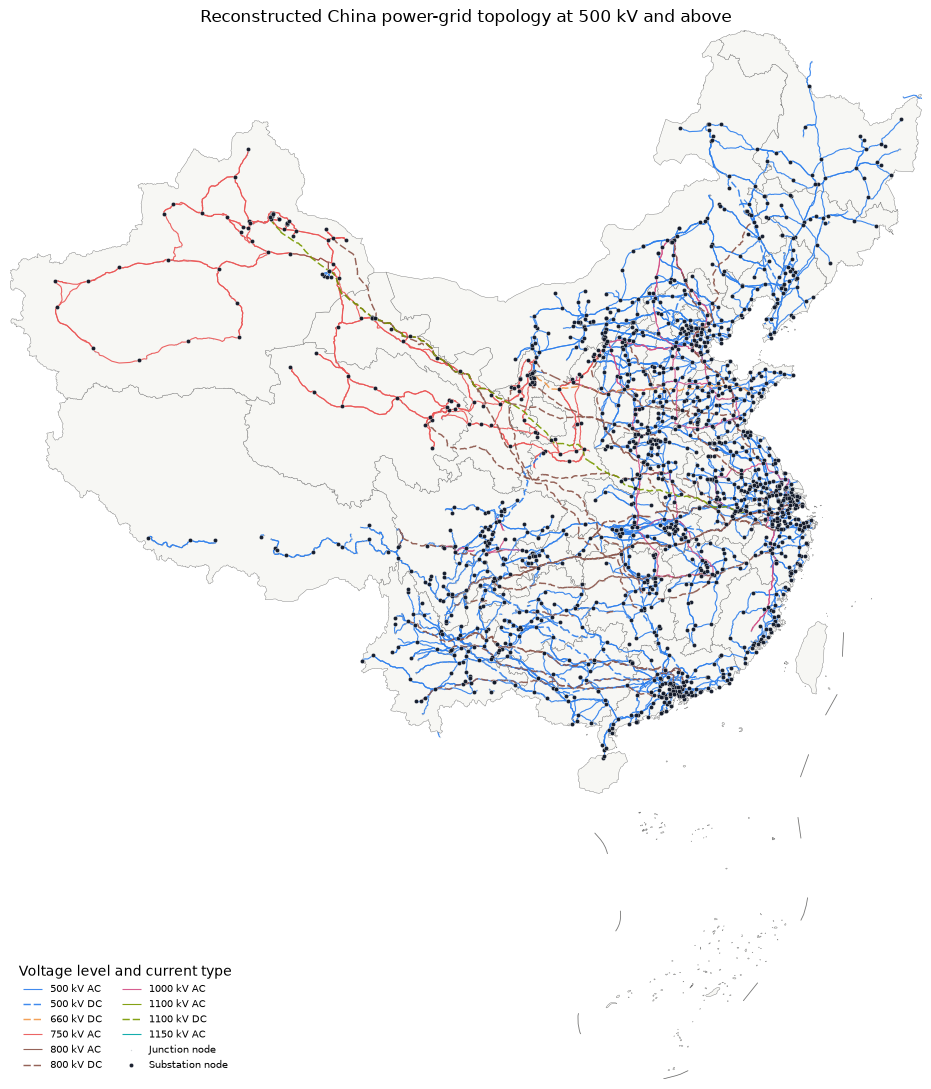

In [10]:
# Expand graph node and branch attributes into GeoDataFrames for GIS operations.
grid_nodes_gdf = gpd.GeoDataFrame(
    [
        {"node_uid": node, **node_data}
        for node, node_data in grid_topology.nodes(data=True)
    ],
    geometry="geometry",
    crs=metric_crs,
)
grid_branches_gdf = gpd.GeoDataFrame(
    [
        {"from_node": node_a, "to_node": node_b, **branch}
        for node_a, node_b, branch in grid_topology.edges(data=True)
    ],
    geometry="geometry",
    crs=metric_crs,
)

_node_points_wgs84 = grid_nodes_gdf.geometry.to_crs("EPSG:4326")
grid_nodes_gdf["node_longitude"] = _node_points_wgs84.x
grid_nodes_gdf["node_latitude"] = _node_points_wgs84.y

_node_province = grid_nodes_gdf.set_index("node_uid")["node_province_name"]
_node_type = grid_nodes_gdf.set_index("node_uid")["node_type"]
grid_branches_gdf["from_node_type"] = grid_branches_gdf["from_node"].map(
    _node_type
)
grid_branches_gdf["to_node_type"] = grid_branches_gdf["to_node"].map(
    _node_type
)
grid_branches_gdf["from_node_province"] = grid_branches_gdf[
    "from_node"
].map(_node_province)
grid_branches_gdf["to_node_province"] = grid_branches_gdf[
    "to_node"
].map(_node_province)
grid_branches_gdf["is_cross_province"] = (
    grid_branches_gdf["from_node_province"].notna()
    & grid_branches_gdf["to_node_province"].notna()
    & grid_branches_gdf["from_node_province"].ne(
        grid_branches_gdf["to_node_province"]
    )
)
grid_branches_gdf["length_km"] = grid_branches_gdf["length_m"] / 1000

station_nodes_gdf = grid_nodes_gdf.query("node_type == 'station'").copy()
station_areas_gdf = gpd.GeoDataFrame(
    _station_metadata.reset_index().merge(
        station_nodes_gdf[[
            "node_uid", "station_uid", "node_voltage_levels_kv",
            "node_province_name", "province_intersection_matched",
            "node_longitude", "node_latitude",
            "in_largest_connected_graph",
        ]],
        on="station_uid",
        how="inner",
    ),
    geometry="geometry",
    crs=metric_crs,
)

fig_topology, ax_topology = plt.subplots(figsize=map_figure_size)
_plot_provinces = provinces.to_crs(metric_crs)
_ = _plot_provinces.plot(
    ax=ax_topology, facecolor="#f7f7f4", edgecolor="#777777",
    linewidth=0.30, zorder=1,
)

for _voltage_level in voltage_order:
    for _current_type, _linestyle in current_styles.items():
        _selected_branches = grid_branches_gdf[
            (grid_branches_gdf["voltage_level"] == _voltage_level)
            & (grid_branches_gdf["current_type"] == _current_type)
        ]
        if not _selected_branches.empty:
            _ = _selected_branches.plot(
                ax=ax_topology,
                color=voltage_styles[_voltage_level],
                linestyle=_linestyle,
                linewidth=1.05 if _current_type == "DC" else 0.80,
                alpha=0.92,
                label=f"{_voltage_level} {_current_type}",
                zorder=3 if _current_type == "DC" else 2,
            )

_ = grid_nodes_gdf.query("node_type == 'junction'").plot(
    ax=ax_topology, marker="o", color="#9CA3AF", markersize=1.0,
    alpha=0.42, linewidth=0, label="Junction node", zorder=4,
)
_ = station_nodes_gdf.plot(
    ax=ax_topology, marker="o", color="#111827", edgecolor="white",
    linewidth=0.22, markersize=9.0, alpha=0.96,
    label="Substation node", zorder=5,
)
_ = ax_topology.legend(
    loc="lower left", frameon=False, fontsize=7, ncol=2,
    title="Voltage level and current type",
)
_ = ax_topology.set(
    xlim=_plot_provinces.total_bounds[[0, 2]],
    ylim=_plot_provinces.total_bounds[[1, 3]],
    title=(
        "Reconstructed China power-grid topology at "
        f"{min_line_voltage / 1000:g} kV and above"
    ),
)
_ = ax_topology.set_axis_off()
plt.tight_layout()
fig_topology.savefig(
    output_dir / "china_grid_topology.png",
    dpi=map_dpi,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

## 11. 标记并绘制最大连通图

不创建新的拓扑或GeoDataFrame对象。本cell直接在已有 `grid_topology` 及其
GIS视图中增加布尔属性 `in_largest_connected_graph`。值为 `True`
表示node或branch属于最大连通图，`False` 表示属于其他连通子图。

独立地图不叠加原始OSM `line_segments`：其他连通子图作为浅灰背景，
最大连通图使用蓝色branch和白色halo突出。

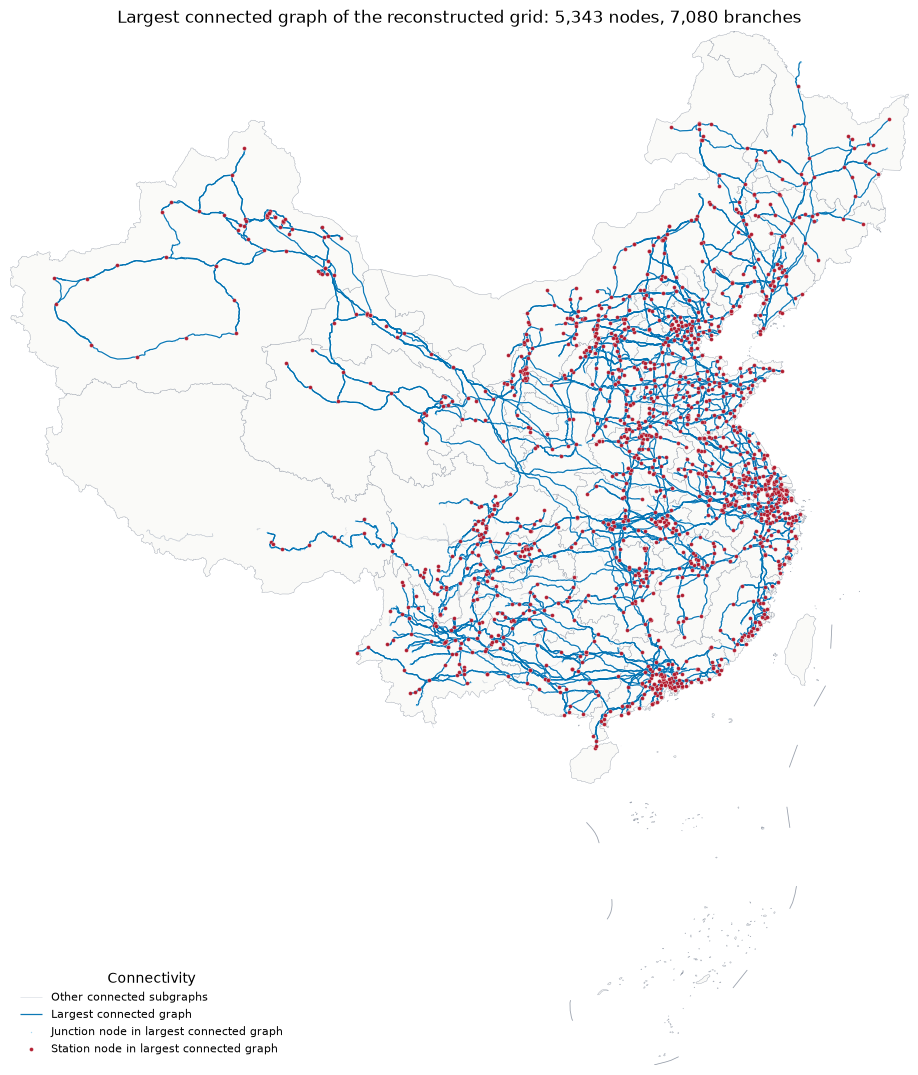

In [11]:
_fig_largest_graph, _ax_largest_graph = plt.subplots(figsize=map_figure_size)
_ = _plot_provinces.plot(
    ax=_ax_largest_graph,
    facecolor="#FAFAF8",
    edgecolor="#9CA3AF",
    linewidth=0.30,
    zorder=1,
)
_ = grid_branches_gdf.loc[
    ~grid_branches_gdf["in_largest_connected_graph"]
].plot(
    ax=_ax_largest_graph,
    color="#B8C0CC",
    linewidth=0.45,
    alpha=0.55,
    label="Other connected subgraphs",
    zorder=2,
)

# The white halo separates the largest connected graph from overlapping context.
_ = grid_branches_gdf.loc[
    grid_branches_gdf["in_largest_connected_graph"]
].plot(
    ax=_ax_largest_graph,
    color="white",
    linewidth=2.0,
    alpha=0.95,
    zorder=3,
)
_ = grid_branches_gdf.loc[
    grid_branches_gdf["in_largest_connected_graph"]
].plot(
    ax=_ax_largest_graph,
    color="#0072B2",
    linewidth=0.90,
    alpha=0.95,
    label="Largest connected graph",
    zorder=4,
)
_ = grid_nodes_gdf.loc[
    grid_nodes_gdf["in_largest_connected_graph"]
    & grid_nodes_gdf["node_type"].eq("junction")
].plot(
    ax=_ax_largest_graph,
    marker="o",
    color="#56B4E9",
    markersize=1.0,
    alpha=0.50,
    linewidth=0,
    label="Junction node in largest connected graph",
    zorder=5,
)
_ = grid_nodes_gdf.loc[
    grid_nodes_gdf["in_largest_connected_graph"]
    & grid_nodes_gdf["node_type"].eq("station")
].plot(
    ax=_ax_largest_graph,
    marker="o",
    color="#B2182B",
    edgecolor="white",
    linewidth=0.22,
    markersize=8.0,
    alpha=0.96,
    label="Station node in largest connected graph",
    zorder=6,
)

_ = _ax_largest_graph.legend(
    loc="lower left",
    frameon=False,
    fontsize=8,
    title="Connectivity",
)
_ = _ax_largest_graph.set(
    xlim=_plot_provinces.total_bounds[[0, 2]],
    ylim=_plot_provinces.total_bounds[[1, 3]],
    title=(
        "Largest connected graph of the reconstructed grid: "
        f"{grid_nodes_gdf['in_largest_connected_graph'].sum():,} "
        "nodes, "
        f"{grid_branches_gdf['in_largest_connected_graph'].sum():,} "
        "branches"
    ),
)
_ = _ax_largest_graph.set_axis_off()
plt.tight_layout()
_fig_largest_graph.savefig(
    output_dir / "china_largest_connected_graph.png",
    dpi=map_dpi,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

In [12]:
_copy = station_nodes_gdf.node_province_name.isna() == True
_copy

0       False
4       False
12      False
14      False
18      False
        ...  
6366    False
6367    False
6375    False
6403    False
6405    False
Name: node_province_name, Length: 1544, dtype: bool